In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

In [12]:
# ── Load Data ─────────────────────────────────────────────────────────────────
# Input : Embedding/6/answers_emb.npy + metadata.pkl (output fasttext.ipynb)
# Output: Embedding/6/ae_answers_emb.npy + ae_metadata.pkl  (Mixup level A-E)
#
# questions_emb & answerkeys_emb TIDAK berubah.

DATA_DIR = os.path.join(os.getcwd(), "Embedding", "6")

LABEL_TO_IDX = {'E': 0, 'D': 1, 'C': 2, 'B': 3, 'A': 4}
IDX_TO_LABEL = {v: k for k, v in LABEL_TO_IDX.items()}
N_CLASSES    = 5

answers_emb    = np.load(os.path.join(DATA_DIR, 'answers_emb.npy'))
questions_emb  = np.load(os.path.join(DATA_DIR, 'questions_emb.npy'))
answerkeys_emb = np.load(os.path.join(DATA_DIR, 'answerkeys_emb.npy'))
metadata       = pd.read_pickle(os.path.join(DATA_DIR, 'metadata.pkl'))
metadata       = metadata.reset_index(drop=True)

# Derivasi label_ae dari labela (string -> integer)
metadata['label_ae']     = metadata['labela'].map(LABEL_TO_IDX)
metadata['is_synthetic'] = False

assert len(metadata) == len(answers_emb)
assert metadata['label_ae'].notna().all(), "Ada labela yang tidak dikenali!"

print("=== Hasil Load ===")
print(f"answers_emb    : {answers_emb.shape}")
print(f"questions_emb  : {questions_emb.shape}  (per IDPSJ, tidak diubah)")
print(f"answerkeys_emb : {answerkeys_emb.shape}  (per IDPSJ, tidak diubah)")
print(f"Metadata       : {len(metadata)} rows")
print(f"Kolom          : {list(metadata.columns)}")
print()
print("Distribusi A-E:")
for idx in range(N_CLASSES):
    n = (metadata['label_ae'] == idx).sum()
    print(f"  {IDX_TO_LABEL[idx]}: {n}")
print(f"Ratio max/min: {metadata['label_ae'].value_counts().max() / metadata['label_ae'].value_counts().min():.2f}x")

=== Hasil Load ===
answers_emb    : (1229, 85, 300)
questions_emb  : (17, 135, 300)  (per IDPSJ, tidak diubah)
answerkeys_emb : (17, 90, 300)  (per IDPSJ, tidak diubah)
Metadata       : 1229 rows
Kolom          : ['IDJwb', 'IDPSJ', 'grade', 'labela', 'psj_idx', 'label_ae', 'is_synthetic']

Distribusi A-E:
  E: 323
  D: 155
  C: 189
  B: 214
  A: 348
Ratio max/min: 2.25x


In [13]:
# ── Analisis Distribusi per IDPSJ (sebelum Mixup A-E) ─────────────────────────
pivot_before = (
    metadata.groupby(['IDPSJ', 'label_ae'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=range(N_CLASSES), fill_value=0)
)
pivot_before.columns = [IDX_TO_LABEL[c] for c in pivot_before.columns]

print("=" * 55)
print("Sampel per A-E per IDPSJ (sebelum Mixup)")
print("=" * 55)
print(pivot_before.to_string())

# Hitung target Mixup per IDPSJ
max_ae_per_idpsj = pivot_before.max(axis=1)
target_per_idpsj = (max_ae_per_idpsj / 1.5).apply(np.ceil).astype(int)

print("\nTarget Mixup (ceil(max/1.5)) per IDPSJ:")
for psj in sorted(metadata['IDPSJ'].unique()):
    row    = pivot_before.loc[psj]
    tgt    = target_per_idpsj[psj]
    kurang = {IDX_TO_LABEL[i]: f"{row.iloc[i]}->{tgt}"
              for i in range(N_CLASSES) if row.iloc[i] < tgt}
    if kurang:
        print(f"  IDPSJ {psj:2d} (target={tgt}): {kurang}")
    else:
        print(f"  IDPSJ {psj:2d} (target={tgt}): semua kelas sudah cukup")

Sampel per A-E per IDPSJ (sebelum Mixup)
        E   D   C   B   A
IDPSJ                    
1      10  10  25  14  42
2      16   5   5  10   5
3       5   5  10   6   7
4      10  16  10  10  20
5      28   5   5   5  10
6      30  10  10  10  11
7       9   8  10  10  20
8      18  11  10  10  63
9      23  10  10  12  48
10     13  10  10  41  40
11     65  10  13  10  22
12      5   5  21   6   8
13     10  10  10  20  10
14     11  10  10  20  12
15     25  10  10  10  10
16     16  10  10  10  10
17     29  10  10  10  10

Target Mixup (ceil(max/1.5)) per IDPSJ:
  IDPSJ  1 (target=28): {'E': '10->28', 'D': '10->28', 'C': '25->28', 'B': '14->28'}
  IDPSJ  2 (target=11): {'D': '5->11', 'C': '5->11', 'B': '10->11', 'A': '5->11'}
  IDPSJ  3 (target=7): {'E': '5->7', 'D': '5->7', 'B': '6->7'}
  IDPSJ  4 (target=14): {'E': '10->14', 'C': '10->14', 'B': '10->14'}
  IDPSJ  5 (target=19): {'D': '5->19', 'C': '5->19', 'B': '5->19', 'A': '10->19'}
  IDPSJ  6 (target=20): {'D': '10->20', 'C

In [14]:
# ── Mixup Level A-E per IDPSJ ─────────────────────────────────────────────────
# Strategi  : intra-class Mixup (dalam kelas A-E yang sama), LINTAS grade
#             Contoh: grade-1 x grade-3 -> tetap kelas E
#                     grade-4 x grade-5 -> tetap kelas D
# Hanya answers_emb yang di-mix; questions & answerkeys tidak berubah.
# Target    : ceil(max_ae_per_idpsj / 1.5) per kelas per IDPSJ
# lambda    : Beta(0.4, 0.4) di-clip ke [0.5, 1.0]

RNG   = np.random.default_rng(seed=42)
ALPHA = 0.4

syn_answers = []
syn_meta    = []

grades_base  = metadata['grade'].values
psj_idx_base = metadata['psj_idx'].values

for psj in sorted(metadata['IDPSJ'].unique()):
    mask_psj    = (metadata['IDPSJ'] == psj).values
    psj_global  = np.where(mask_psj)[0]            # indeks ke answers_emb / metadata
    psj_labels  = metadata['label_ae'].values[psj_global]
    ae_counts   = np.bincount(psj_labels, minlength=N_CLASSES)
    local_max   = ae_counts.max()
    target      = int(np.ceil(local_max / 1.5))
    psj_idx_val = psj_idx_base[psj_global[0]]       # sama untuk seluruh IDPSJ

    for ae_cls in range(N_CLASSES):
        cls_global = psj_global[psj_labels == ae_cls]  # indeks ke answers_emb
        n_cls      = len(cls_global)
        if n_cls == 0 or n_cls >= target:
            continue

        n_needed = target - n_cls

        # Pasangan Mixup dipilih dalam kelas A-E yang sama (boleh beda grade)
        idx_i = RNG.choice(cls_global, size=n_needed, replace=True)
        idx_j = RNG.choice(cls_global, size=n_needed, replace=True)

        lam    = np.clip(RNG.beta(ALPHA, ALPHA, size=n_needed), 0.5, 1.0)
        lam_bc = lam.reshape((n_needed,) + (1,) * (answers_emb.ndim - 1))

        syn_answers.append(lam_bc * answers_emb[idx_i] + (1 - lam_bc) * answers_emb[idx_j])

        # Grade: rata-rata tertimbang (informatif, label_ae yang dipakai saat training)
        mixed_grades = lam * grades_base[idx_i] + (1 - lam) * grades_base[idx_j]

        for k in range(n_needed):
            syn_meta.append({
                'IDJwb'        : f'ae_{psj}_{IDX_TO_LABEL[ae_cls]}_{k}',
                'IDPSJ'        : psj,
                'grade'        : mixed_grades[k],
                'psj_idx'      : psj_idx_val,
                'is_synthetic' : True,
                'label_ae'     : ae_cls,
            })

# ── Gabungkan ─────────────────────────────────────────────────────────────────
if syn_answers:
    ae_answers_emb = np.vstack([answers_emb] + syn_answers)
    ae_metadata    = pd.concat([metadata, pd.DataFrame(syn_meta)], ignore_index=True)
else:
    ae_answers_emb = answers_emb.copy()
    ae_metadata    = metadata.copy()

n_syn = len(ae_metadata) - len(metadata)
print(f"Base (real+CPI): {len(metadata)}")
print(f"Sintetis baru   : {n_syn}")
print(f"Total           : {len(ae_metadata)}")
print(f"ae_answers_emb  : {ae_answers_emb.shape}")

Base (real+CPI): 1229
Sintetis baru   : 695
Total           : 1924
ae_answers_emb  : (1924, 85, 300)


Sampel per A-E per IDPSJ (setelah Mixup A-E)
        E   D   C   B   A
IDPSJ                    
1      28  28  28  28  42
2      16  11  11  11  11
3       7   7  10   7   7
4      14  16  14  14  20
5      28  19  19  19  19
6      30  20  20  20  20
7      14  14  14  14  20
8      42  42  42  42  63
9      32  32  32  32  48
10     28  28  28  41  40
11     65  44  44  44  44
12     14  14  21  14  14
13     14  14  14  20  14
14     14  14  14  20  14
15     25  17  17  17  17
16     16  11  11  11  11
17     29  20  20  20  20

Distribusi global A-E:
  E: 416
  D: 351
  C: 359
  B: 374
  A: 424
Ratio max/min: 1.21x

Perbandingan distribusi global:
Kelas     Sebelum    Sesudah   Tambahan
  E           323        416        +93
  D           155        351       +196
  C           189        359       +170
  B           214        374       +160
  A           348        424        +76


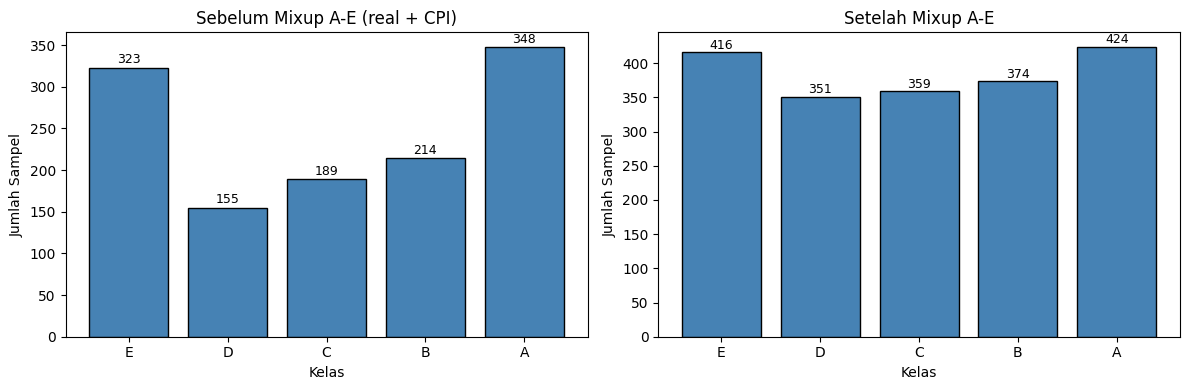

In [15]:
# ── Analisis Distribusi Setelah Mixup A-E ─────────────────────────────────────
pivot_after = (
    ae_metadata.groupby(['IDPSJ', 'label_ae'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=range(N_CLASSES), fill_value=0)
)
pivot_after.columns = [IDX_TO_LABEL[c] for c in pivot_after.columns]

print("=" * 55)
print("Sampel per A-E per IDPSJ (setelah Mixup A-E)")
print("=" * 55)
print(pivot_after.to_string())

print("\nDistribusi global A-E:")
cnt_after = ae_metadata['label_ae'].value_counts().sort_index()
for idx in range(N_CLASSES):
    n = cnt_after.get(idx, 0)
    print(f"  {IDX_TO_LABEL[idx]}: {n}")
print(f"Ratio max/min: {cnt_after.max() / cnt_after.min():.2f}x")

# Bandingkan sebelum vs sesudah
print("\nPerbandingan distribusi global:")
cnt_before = metadata['label_ae'].value_counts().sort_index()
print(f"{'Kelas':<6} {'Sebelum':>10} {'Sesudah':>10} {'Tambahan':>10}")
for idx in range(N_CLASSES):
    b = cnt_before.get(idx, 0)
    a = cnt_after.get(idx, 0)
    print(f"  {IDX_TO_LABEL[idx]:<4} {b:>10} {a:>10} {a-b:>+10}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels = [IDX_TO_LABEL[i] for i in range(N_CLASSES)]
for ax, (title, cnt) in zip(axes, [
    ("Sebelum Mixup A-E (real + CPI)", cnt_before),
    ("Setelah Mixup A-E",              cnt_after)
]):
    vals = [cnt.get(i, 0) for i in range(N_CLASSES)]
    ax.bar(labels, vals, color='steelblue', edgecolor='black')
    ax.set_title(title)
    ax.set_ylabel('Jumlah Sampel')
    ax.set_xlabel('Kelas')
    for j, v in enumerate(vals):
        ax.text(j, v + 5, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'ae_distribution.png'), dpi=150)
plt.show()

In [16]:
# ── Simpan ────────────────────────────────────────────────────────────────────
# ae_answers_emb.npy : answers setelah Mixup A-E (per sampel)
# ae_metadata.pkl    : metadata dengan kolom label_ae + psj_idx
#
# questions_emb & answerkeys_emb TIDAK disimpan ulang.
# Training notebook menggunakan questions_emb.npy + answerkeys_emb.npy
# dengan psj_idx sebagai kunci (mapping tidak berubah).

np.save(os.path.join(DATA_DIR, 'ae_answers_emb.npy'), ae_answers_emb)
ae_metadata.to_pickle(os.path.join(DATA_DIR, 'ae_metadata.pkl'))

print("File tersimpan:")
print(f"  ae_answers_emb.npy   {ae_answers_emb.shape}  (per sampel)")
print(f"  ae_metadata.pkl      {len(ae_metadata)} rows")
print(f"  Kolom metadata       : {list(ae_metadata.columns)}")
print()
print("File yang tetap dipakai di training (tidak berubah):")
print(f"  questions_emb.npy    {questions_emb.shape}")
print(f"  answerkeys_emb.npy   {answerkeys_emb.shape}")
print()
# Verifikasi psj_idx konsisten
print("Verifikasi psj_idx:")
for psj in sorted(ae_metadata['IDPSJ'].unique()):
    idx_vals = ae_metadata.loc[ae_metadata['IDPSJ'] == psj, 'psj_idx'].unique()
    assert len(idx_vals) == 1, f"psj_idx tidak konsisten untuk IDPSJ {psj}: {idx_vals}"
print("  OK — setiap IDPSJ memiliki tepat satu psj_idx")

File tersimpan:
  ae_answers_emb.npy   (1924, 85, 300)  (per sampel)
  ae_metadata.pkl      1924 rows
  Kolom metadata       : ['IDJwb', 'IDPSJ', 'grade', 'labela', 'psj_idx', 'label_ae', 'is_synthetic']

File yang tetap dipakai di training (tidak berubah):
  questions_emb.npy    (17, 135, 300)
  answerkeys_emb.npy   (17, 90, 300)

Verifikasi psj_idx:
  OK — setiap IDPSJ memiliki tepat satu psj_idx
